### Image classifier for the SVHN dataset

In [1]:
#importing libraries

import tensorflow as tf
from scipy.io import loadmat
import matplotlib.pyplot as plt
import numpy as np
import random

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

In [2]:
train = loadmat("D:\\Tensorflow_Works\\15-Image_Classifier_For_SVHN_Dataset\\data\\train_32x32.mat")
test = loadmat("D:\\Tensorflow_Works\\15-Image_Classifier_For_SVHN_Dataset\\data\\test_32x32.mat")

In [3]:
train.keys()

dict_keys(['__header__', '__version__', '__globals__', 'X', 'y'])

In [4]:
train['X'].shape

(32, 32, 3, 73257)

In [5]:
#inspecting dataset

x_train = np.transpose(train['X'], (3,0,1,2))
y_train = np.transpose(train['y'], (0,1))

x_test = np.transpose(test['X'], (3,0,1,2))
y_test = np.transpose(test['y'], (0,1))

print(x_train.shape)
print(y_train.shape)
print(f"\n{x_test.shape}")
print(y_test.shape)



(73257, 32, 32, 3)
(73257, 1)

(26032, 32, 32, 3)
(26032, 1)


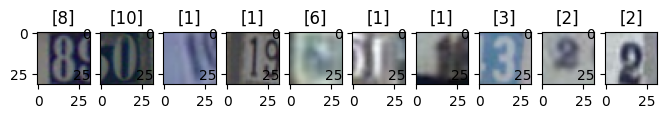

In [6]:
#some sample images

num_samples = x_train.shape[0]
n_index = np.random.choice(num_samples, 10)
plt.subplots(1,10, figsize=(8,12))
for n, i in enumerate(n_index):
    plt.subplot(1, 10, n+1)
    plt.imshow(x_train[i])
    plt.title(y_train[i])


In [ ]:
#function to convert images to monochrome

def monochrome(x):
    avg_color = np.mean(x, axis=-1, keepdims=True)
    return np.repeat(avg_color, 3, axis=-1)

x_train_grey = monochrome(x_train)
x_test_grey = monochrome(x_test)

In [12]:
#rescaling values between 0 -1

x_train_grey = x_train_grey/255.
x_test_grey = x_test_grey/255.

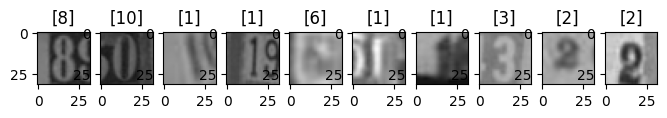

In [13]:
#some sample grey images

plt.subplots(1,10, figsize=(8,12))
for n, i in enumerate(n_index):
    plt.subplot(1, 10, n+1)
    plt.imshow(x_train_grey[i])
    plt.title(y_train[i])